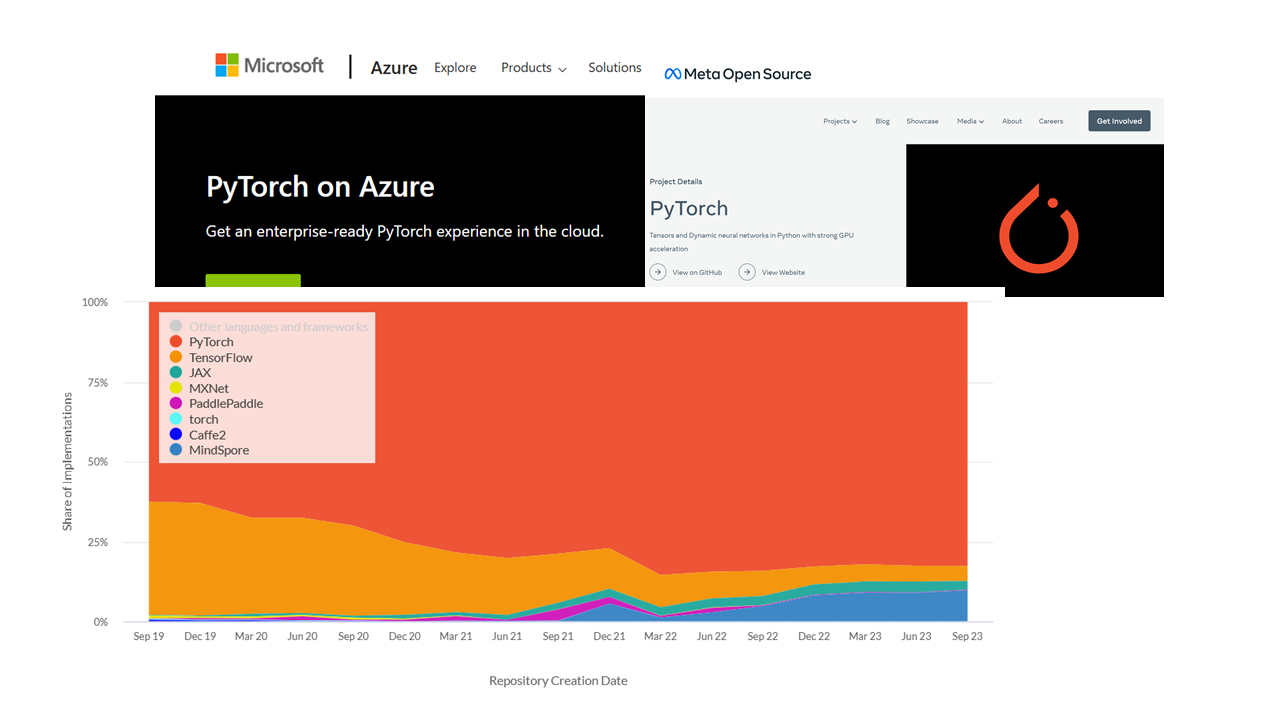

In [4]:
from IPython.display import Image
Image('/content/Obraz1.png')

# Ćw.1 Podstawy PyTorch

## Czym jest PyTorch?

[PyTorch](https://pytorch.org/) to platforma uczenia maszynowego i uczenia głębokiego typu open source oparta na bibliotece Torch,
używana do zastosowań takich jak wizja komputerowa i przetwarzanie języka naturalnego, pierwotnie opracowana przez Meta AI, a obecnie część Linux Foundation.
Jest to jeden z najpopularniejszych frameworków głębokiego uczenia się, obok innych, takich jak TensorFlow i Keras.
    

## Jakie jest zastosowanie PyTorch?

PyTorch umożliwia przetwarzanie danych oraz pisanie algorytmów uczenia maszynowego przy użyciu kodu Pythona.

## Gdzie PyTorch jest wykorzystywany?

PyTorch jest wykorzystywany przez wiele z największych na świecie firm technologicznych, takich jak [Meta (Facebook)](https://ai.facebook.com/blog/pytorch-builds-the-future-of-ai-and-machine-learning-at-facebook/),
Tesla, Microsoft, a także firmy związane z rozwojem AI, np.  [OpenAI](https://openai.com/blog/openai-pytorch/).

![Obraz1](Obraz1.png)

 Andrej Karpathy (szef AI w Tesli) opowiada jak  Tesla wykorzystuje PyTorch w nawigacji samochodów autonomicznych: ([PyTorch DevCon 2019](https://youtu.be/oBklltKXtDE), [Tesla AI Day 2021](https://youtu.be/j0z4FweCy4M?t=2904))  
                                                                           

Przykład użycia w rolnictwie (https://medium.com/pytorch/ai-for-ag-production-machine-learning-for-agriculture-e8cfdb9849a1).

## Po co PyTorch?

Możemy skupić się na obróbce danych i pisaniu algorytmów, a PyTorch zapewnia ich szybkie działanie.

A jeśli firmy takie jak Tesla i Meta (Facebook) używają go do budowania modeli, które są wykorzystywane do zasilania setek aplikacji,
prowadzenia autonomicznych samochodów i dostarczania treści miliardom ludzi.
## Zawartość ćwiczeń

Zawartość ćwiczeń:

| **Temat** | **Zawartość** |
| ----- | ----- |
| **Wstęp do Tensorów** | Tensory są podstawowym budulcem całego uczenia maszynowego i głębokiego uczenia. |
| **Tworzenie tensorów** | Tensory mogą reprezentować prawie każdy rodzaj danych (obrazy, słowa, tablice liczb). |
| **Pobieranie informacji z tensorów** | Jeśli możesz umieścić informacje w tensorze, będziesz chciał je również wydobyć. |
| **Operacje na tensorach** | Algorytmy uczenia maszynowego (takie jak sieci neuronowe) obejmują operowanie tensorami na wiele różnych sposobów, takich jak dodawanie, mnożenie, łączenie. |
| **Problem wymiarowości** |Jednym z najczęstszych problemów w uczeniu maszynowym jest radzenie sobie z niedopasowaniem kształtów (próba mieszania tensorów o niewłaściwych kształtach z innymi tensorami). |
| **Indeksowanie na tensorach** | Jeśli indeksowałeś na liście Pythona lub tablicy NumPy, jest to bardzo podobne do tensorów, z wyjątkiem tego, że mogą one mieć znacznie więcej wymiarów. |
| **Mieszanie tensorów PyTorch i NumPy** | PyTorch bawi się tensorami ([`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html)), NumPy lubi tablice ([`np.ndarray`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.html)) czasami będziesz chciał je mieszać i łączyć. |
| **Powtarzalność** |Uczenie maszynowe jest bardzo eksperymentalne, a ponieważ wykorzystuje dużo *losowości* do pracy, czasami będziesz chciał, aby ta *losowość* nie była tak losowa. |
| **Praca na GPU** | GPU (Graphics Processing Units) sprawiają, że kod jest szybszy, PyTorch ułatwia uruchamianie kodu na GPU. |


## Instalacja PyTorcha
>**Uwaga:** Przed uruchomieniem jakiegokolwiek kodu w tym notatniku, należy przejść przez [kroki konfiguracji PyTorch](https://pytorch.org/get-started/locally/).

> Jeśli jednak korzystasz z **Google Colab**, wszystko powinno działać (Google Colab jest dostarczany z zainstalowanym PyTorch i innymi bibliotekami).

>Import PyTorcha i sprawdzenie wersji, której używamy.


#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

In [5]:
import torch
torch.__version__

'2.10.0+cu128'

## Wstęp do Tensorów

Tensory są podstawowym elementem składowym uczenia maszynowego.

Ich zadaniem jest reprezentowanie danych w sposób numeryczny.

Na przykład, można przedstawić obraz jako tensor o kształcie `[3, 360, 280]`, co oznaczałoby `[kanały kolorów, wysokość, szerokość]`, ponieważ obraz ma `3` kanały kolorów (czerwony, zielony, niebieski), wysokość `360` pikseli i szerokość `280` pikseli.

W języku używanym do opisywania tensorów, tensor miałby trzy wymiary, po jednym dla `colour_channels`, `wysokość` i `szerokość`.



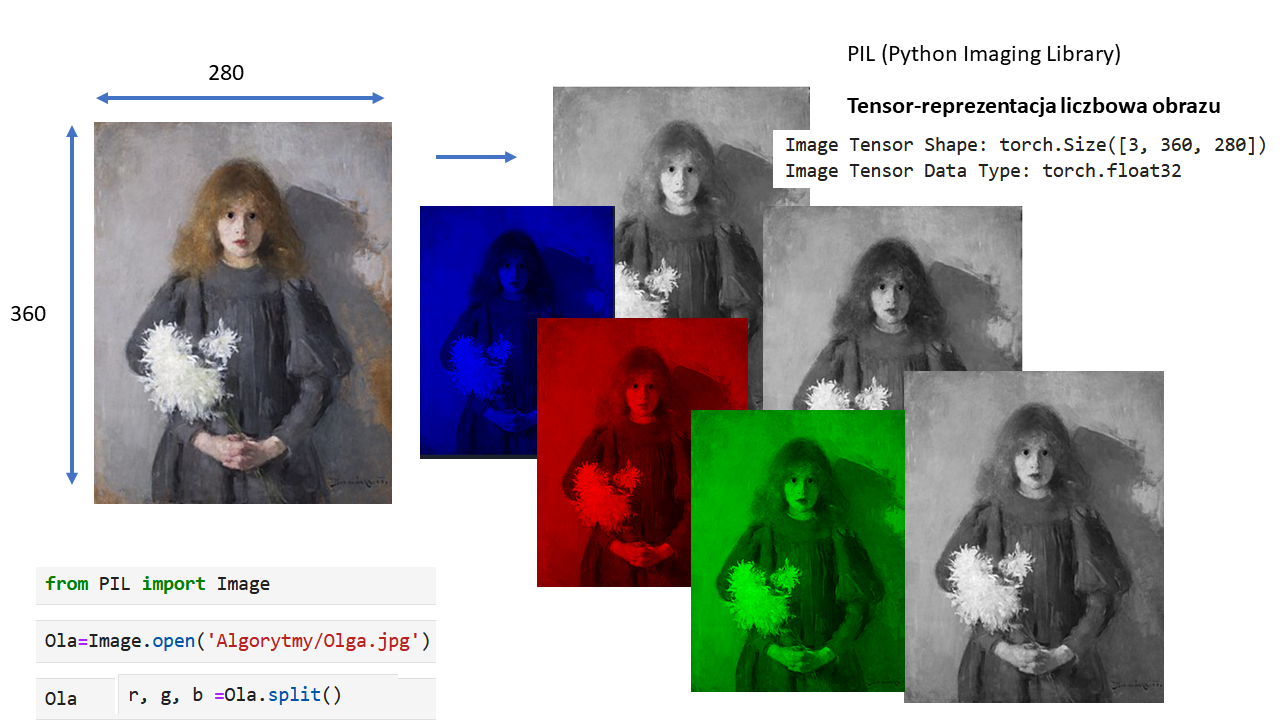

In [89]:

Image('/content/Obraz2.PNG')

### Tworzenie tensorów

PyTorch jest oparty na tensorach. Wkład w ich rozwój ma polski informatyk Adam Paszke.
Dokumentację dotyczącą tensorów można znaleźć tu: [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html).

Pierwszą rzeczą, którą utworzymy jest **skalar**.

Skalar to pojedyncza liczba, a w języku tensorów jest to tensor o zerowym wymiarze.


In [6]:
# Skalar
scalar = torch.tensor(7)
scalar

tensor(7)

Dlaczego wynikiem jest `tensor(7)`?

Oznacza to, że chociaż `scalar` jest pojedynczą liczbą, to jest typu `torch.Tensor`.

Możemy sprawdzić wymiary tensora używając atrybutu `ndim`.

In [7]:
scalar.ndim

0

Co jeśli chcielibyśmy pobrać liczbę z tensora?

W sensie, przekształcić go z `torch.Tensor` na liczbę całkowitą Pythona?

Aby to zrobić, możemy użyć metody `item()`.

In [8]:
# Zamiana na liczbę Pythona w tensorze (działa tylko z tensorami jednoelementowymi)
scalar.item()

7

Sprawdzimy jak wyglądają  **wektory**.
Wektor jest tensorem o  wymiarze 1, ale może zawierać wiele liczb.

In [9]:
# Wektor
vector = torch.tensor([7, 7])
vector

tensor([7, 7])

Jaki jest wymiar wektora?

In [10]:
# Sprawdzenie wymiaru wektora
vector.ndim

1

Możesz określić liczbę wymiarów tensora w PyTorch na podstawie liczby nawiasów kwadratowych na zewnątrz (`[`) i musisz policzyć tylko jedną stronę.
Ile nawiasów kwadratowych ma `vector`?
Innym ważnym pojęciem dla tensorów jest ich atrybut `shape`. Kształt mówi o tym, jak ułożone są elementy wewnątrz tensora.
Sprawdźmy kształt `wektora`.

In [11]:
# Sprawdzamy shape
vector.shape

torch.Size([2])

Powyższe zwraca torch.Size([2]), co oznacza, że nasz wektor ma kształt [2]. Wynika to z dwóch elementów, które umieściliśmy wewnątrz nawiasów kwadratowych ([7, 7]).

Zobaczmy teraz **macierz**.

In [12]:
# Macierz
MATRIX = torch.tensor([[7, 8, 7],
                       [9, 10, 3]])
MATRIX

tensor([[ 7,  8,  7],
        [ 9, 10,  3]])

In [13]:
# Sprawdzenie liczby wymiarów
MATRIX.ndim

2

`MATRIX` ma dwa wymiary (liczba nawiasów kwadratowych po zewnętrznej stronie jednego boku).

Jaki jest kształt `shape` macierzy?

In [14]:
MATRIX.shape

torch.Size([2, 3])

Otrzymujemy wynik `torch.Size([2, 3])` ponieważ `MATRIX` ma 2 wiersze i 3 kolumny.

Stworzymy teraz sami **tensor**.

In [15]:
# Tensor
TENSOR = torch.tensor([[[1, 2, 3],
                        [3, 6, 9],
                        [2, 4, 5]]])
TENSOR

tensor([[[1, 2, 3],
         [3, 6, 9],
         [2, 4, 5]]])

In [16]:
# Liczba wymiarów TENSORA
TENSOR.ndim

3

Sprawdzimy kształt.

In [17]:
# Kształt TENSORA
TENSOR.shape

torch.Size([1, 3, 3])

Jak rozumieć `torch.Size([1, 3, 3])`?

Wymiary idą od zewnętrznego do wewnętrznego.

Oznacza to, że istnieje 1 wymiar 3 na 3.

> **Uwaga:** Używamy małych liter dla `scalar` i `vector` oraz wielkich liter dla `MATRIX` i `TENSOR`. Było to celowe. W praktyce skalary i wektory są często oznaczane małymi literami, takimi jak `y` lub `a`. Natomiast macierze i tensory są oznaczane wielkimi literami, takimi jak `X` lub `W`.
>
> Można również zauważyć, że nazwy martrix i tensor są używane zamiennie. Jest to powszechne. Ponieważ w PyTorch często mamy do czynienia z `torch.Tensor` (stąd nazwa tensor), jednak kształt i wymiary tego, co jest w środku, będą dyktować, czym on właściwie jest.


| Nazwa | Czym jest? | Liczba wymiarów | Mała lub duża |
| ----- | ----- | ----- | ----- |
| **scalar** | liczba | 0 | Mała (`a`) |
| **vector** | uporządkowana para punktów (kierunek, zwrot)  | 1 | Mała (`y`) |
| **matrix** |  2-wymiarowa tablica liczb | 2 | Duża (`Q`) |
| **tensor** |  n-wymiarowa tablica liczb | może być liczbą,  0-wymiarowy tensor jest skalarem,  1-wymiarowy tensor jest wektorem | Duża (`X`) |



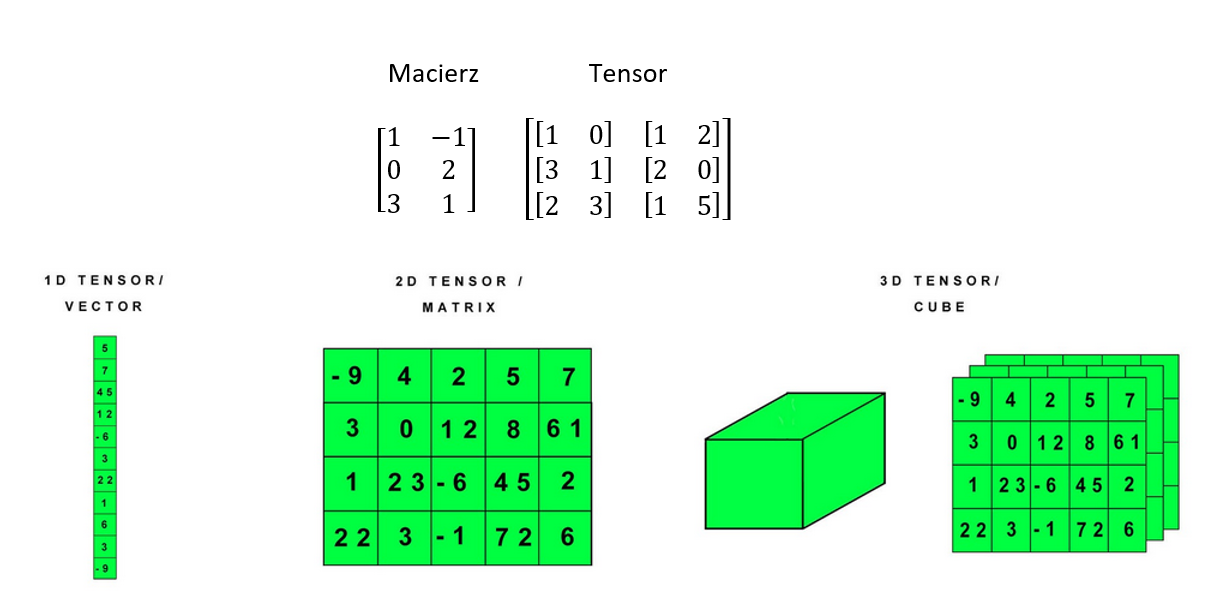

In [92]:
Image('/content/Obraz3.png')

### Losowe tensory

Ustaliliśmy, że tensory reprezentują pewną formę danych.

Modele uczenia maszynowego, takie jak sieci neuronowe, manipulują i szukają wzorców w tensorach.

Jednak podczas budowania modeli uczenia maszynowego za pomocą PyTorch rzadko tworzy się tensory ręcznie (tak jak to robiliśmy).

Zamiast tego model uczenia maszynowego często zaczyna się od dużych losowych tensorów liczb i dostosowuje te losowe liczby w miarę pracy z danymi, aby lepiej je reprezentować.

Zasadniczo:

„Zacznij od liczb losowych -> spójrz na dane -> zaktualizuj liczby losowe -> spójrz na dane -> zaktualizuj liczby losowe...”.

Jako naukowiec zajmujący się danymi możesz zdefiniować, w jaki sposób model uczenia maszynowego uruchamia się (inicjalizacja), patrzy na dane (reprezentacja) i aktualizuje (optymalizacja) swoje liczby losowe.

Później zajmiemy się tymi krokami.

Na razie zobaczmy, jak utworzyć tensor liczb losowych.
We can do so using [`torch.rand()`](https://pytorch.org/docs/stable/generated/torch.rand.html) and passing in the `size` parameter.

In [18]:
# Utwórz losowy tensor o rozmiarze (3, 4)
random_tensor = torch.rand(size=(3, 4))
random_tensor, random_tensor.dtype

(tensor([[0.9773, 0.7409, 0.8432, 0.7974],
         [0.0012, 0.6245, 0.5792, 0.0231],
         [0.3467, 0.7064, 0.8181, 0.8069]]),
 torch.float32)

Elastyczność funkcji torch.rand() polega na tym, że możemy dostosować rozmiar do tego, co chcemy.

Na przykład, powiedzmy, że chcesz uzyskać losowy tensor w typowym kształcie obrazu [224, 224, 3] ([wysokość, szerokość, color_channels]).

In [19]:
# Utwórz losowy tensor o rozmiarze (224, 224, 3)
random_image_size_tensor = torch.rand(size=(224, 224, 3))
random_image_size_tensor.shape, random_image_size_tensor.ndim

(torch.Size([224, 224, 3]), 3)

### Zera i jedynki

Czasami chcemy po prostu wypełnić tensory zerami lub jedynkami.

Dzieje się tak często w przypadku maskowania (np. maskowania niektórych wartości w jednym tensorze zerami, aby model wiedział, że nie powinien się ich uczyć).

Stwórzmy tensor pełen zer za pomocą [`torch.zeros()`](https://pytorch.org/docs/stable/generated/torch.zeros.html)

Ponownie w grę wchodzi parametr `size`.

In [20]:
# Tworzymy tensor 0
zeros = torch.zeros(size=(3, 4))
zeros, zeros.dtype

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 torch.float32)

Możemy zrobić to samo, aby utworzyć tensor  jedynek z użyciem [`torch.ones()` ](https://pytorch.org/docs/stable/generated/torch.ones.html).

In [21]:
# Tworzymy tensor jedynek
ones = torch.ones(size=(3, 4))
ones, ones.dtype

(tensor([[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]),
 torch.float32)

### Tworzenie serii wartości

Czasami potrzebujemy zakresu liczb, takiego jak od 1 do 10 lub od 0 do 100.

W tym celu można użyć `torch.arange(start, end, step)`.

Gdzie:
* `start` = początek zakresu (np. 0)
* `end` = koniec zakresu (np. 10)
* `step` = liczba kroków pomiędzy każdą wartością (np. 1)

> Uwaga:** W Pythonie można użyć funkcji `range()` do utworzenia zakresu. Jednak w PyTorch, `torch.range()` jest przestarzałe i może wyświetlać błąd w przyszłości.


In [22]:
# Use torch.arange(), torch.range() is deprecated
zero_to_ten_deprecated = torch.range(0, 10) # Note: this may return an error in the future

# Create a range of values 0 to 10
zero_to_ten = torch.arange(start=0, end=10, step=1)
zero_to_ten

/tmp/ipython-input-462/1814108326.py:2: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  zero_to_ten_deprecated = torch.range(0, 10) # Note: this may return an error in the future


tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

Czasami może być potrzebny tensor określonego typu o takim samym kształcie jak inny tensor.

Na przykład, tensor wszystkich zer o takim samym kształcie jak poprzedni tensor.

W tym celu można użyć [`torch.zeros_like(input)`](https://pytorch.org/docs/stable/generated/torch.zeros_like.html) lub [`torch.ones_like(input)`](https://pytorch.org/docs/1.9.1/generated/torch.ones_like.html), które zwracają tensor wypełniony odpowiednio zerami lub jedynkami o takim samym kształcie jak `input`.

In [23]:
# Tworzenie tensora zer o tym samym kształcie co inny
ten_zeros = torch.zeros_like(input=zero_to_ten) # ma ten sam kształt
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Tensorowe typy danych

Istnieje wiele różnych [tensorowych typów danych dostępnych w PyTorch](https://pytorch.org/docs/stable/tensors.html#data-types).

Niektóre są specyficzne dla CPU, a niektóre są lepsze dla GPU.

Poznanie, który z nich wykorzystać może zająć trochę czasu.

Ogólnie rzecz biorąc, jeśli gdziekolwiek widzimy `torch.cuda`, tensor jest używany dla GPU (ponieważ procesory graficzne Nvidia używają zestawu narzędzi obliczeniowych o nazwie CUDA).

Najpopularniejszym typem (i generalnie domyślnym) jest `torch.float32` lub `torch.float`.

Jest on określany jako „32-bitowy zmiennoprzecinkowy”.

Ale jest też 16-bitowy zmiennoprzecinkowy (`torch.float16` lub `torch.half`) i 64-bitowy zmiennoprzecinkowy (`torch.float64` lub `torch.double`).

A żeby jeszcze bardziej namieszać, są też 8-bitowe, 16-bitowe, 32-bitowe i 64-bitowe liczby całkowite.



**Uwaga:** Liczba całkowita jest płaską, okrągłą liczbą, taką jak `7`, podczas gdy liczba zmiennoprzecinkowa ma wartość dziesiętną `7.0`.

Powodem tego jest **precyzja w obliczeniach**.

Precyzja to ilość szczegółów użytych do opisania liczby.

Im wyższa wartość precyzji (8, 16, 32), tym więcej szczegółów, a tym samym danych użytych do wyrażenia liczby.

Ma to znaczenie w głębokim uczeniu się i obliczeniach numerycznych, ponieważ wykonujesz tak wiele operacji, im więcej szczegółów musisz obliczyć, tym więcej obliczeń musisz użyć.

Tak więc typy danych o niższej precyzji są generalnie szybsze w obliczeniach, ale poświęcają pewną wydajność w metrykach oceny, takich jak dokładność (szybsze w obliczeniach, ale mniej dokładne).

**Źródła:**
  * Lista wszystkich dostępnych tensorowych typów danych znajduje się w [dokumentacji PyTorch](https://pytorch.org/docs/stable/tensors.html#data-types).
  * Przeczytaj stronę [Wikipedii](https://en.wikipedia.org/wiki/Precision_(computer_science)), aby dowiedzieć się czym jest precyzja w obliczeniach.

Zobaczmy, jak utworzyć tensory z określonymi typami danych. Możemy to zrobić za pomocą parametru `dtype`.

In [24]:
# Domyślnym typem danych dla tensorów jest float32
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # Domyślnie  None, co jest torch.float32
                               device=None, # domyślnie przyjmuje wartość None, która wykorzystuje domyślny typ tensora
                               requires_grad=False) # jeśli True, operacje wykonywane na tensorze są rejestrowane

float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

(torch.Size([3]), torch.float32, device(type='cpu'))

Oprócz problemów z kształtem (kształty tensorów nie pasują do siebie), dwa inne najczęstsze problemy, na które można natknąć się w PyTorch, to problemy z typem danych i urządzeniami.

Na przykład, jeden z tensorów ma format torch.float32, a drugi torch.float16 (PyTorch lubi, gdy tensory mają ten sam format).

Lub jeden z tensorów znajduje się na CPU, a drugi na GPU (PyTorch lubi, gdy obliczenia między tensorami odbywają się na tym samym urządzeniu).

Później zobaczymy więcej na temat tego urządzenia.

Na razie stwórzmy tensor z rozszerzeniem
 `dtype=torch.float16`.

In [25]:
float_16_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=torch.float16) # torch.half także działa

float_16_tensor.dtype

torch.float16

## Uzyskiwanie informacji z tensorów

Po utworzeniu tensorów (lub utworzeniu ich przez kogoś innego lub moduł PyTorch), możemy uzyskać z nich pewne informacje.

Widzieliśmy je już wcześniej, ale trzy z najczęstszych atrybutów, których możemy się dowiedzieć o tensorach to:
* `shape` - jaki kształt ma tensor? (niektóre operacje wymagają określonych reguł kształtu)
* `dtype` - w jakim typie danych przechowywane są elementy tensora?
* `device` - na jakim urządzeniu przechowywany jest tensor? (zazwyczaj GPU lub CPU)

Stwórzmy losowy tensor i poznajmy szczegóły na jego temat.

In [26]:
# Zbuduj tensor
some_tensor = torch.rand(3, 4)

# Szczegóły o tensorze
print(some_tensor)
print(f"Kształt tensora: {some_tensor.shape}")
print(f"Typ danych tensora: {some_tensor.dtype}")
print(f"Urządzenie, na którym jest tensor: {some_tensor.device}") # domyslnie CPU

tensor([[0.7388, 0.8113, 0.8135, 0.5297],
        [0.8385, 0.6899, 0.9822, 0.8405],
        [0.4603, 0.0318, 0.3113, 0.5443]])
Kształt tensora: torch.Size([3, 4])
Typ danych tensora: torch.float32
Urządzenie, na którym jest tensor: cpu


> **Uwaga:** Kiedy napotkasz problemy w PyTorch, bardzo często jest to związane z jednym z trzech powyższych atrybutów.

## Operacje na tensorach

W uczeniu głębokim dane (obrazy, tekst, wideo, audio, struktury białek itp.) są reprezentowane jako tensory.

Model uczy się, badając te tensory i wykonując serię operacji (może być ich ponad 1 000 000) na tensorach, aby stworzyć reprezentację wzorców w danych wejściowych.

Operacje te to:
* dodawanie
* odejmowanie
* mnożeniem (z uwzględnieniem elementów)
* dzielenie
* mnożenie macierzy

I to wszystko. Oczywiście jest jeszcze kilka innych, ale są to podstawowe elementy składowe sieci neuronowych.

Układając te klocki we właściwy sposób, można tworzyć najbardziej wyrafinowane sieci neuronowe (zupełnie jak klocki lego!).

### Podstawowe działania

Podstawowe działania: dodawanie (`+`), odejmowanie (`-`), mnożenie (`*`).


In [27]:
# Utwórz tensor wartości i dodaj do niego liczbę
tensor = torch.tensor([1, 2, 3])
tensor + 10

tensor([11, 12, 13])

In [28]:
# Mnożenie razy 10
tensor * 10

tensor([10, 20, 30])

Zauważ, że powyższe wartości tensora nie skończyły jako `tensor([110, 120, 130])`, ponieważ wartości wewnątrz tensora nie zmieniają się, chyba że zostaną ponownie przypisane.

In [29]:
# Tensory nie zmieniają się, chyba że zostaną ponownie przypisane
tensor

tensor([1, 2, 3])

Odejmijmy liczbę i tym razem ponownie przypiszmy zmienną tensora.

In [30]:
# odjemij i przypisz
tensor = tensor - 10
tensor

tensor([-9, -8, -7])

In [31]:
# Dodaj i  przypisz.
tensor = tensor + 10
tensor

tensor([1, 2, 3])

PyTorch posiada również kilka wbudowanych funkcji, takich jak [`torch.mul()`](https://pytorch.org/docs/stable/generated/torch.mul.html#torch.mul) (skrót od mnożenia) i [`torch.add()`](https://pytorch.org/docs/stable/generated/torch.add.html) do wykonywania podstawowych operacji.

In [32]:
# Można wykorzystywać funkcję torcha
torch.multiply(tensor, 10)

tensor([10, 20, 30])

In [33]:
# Wyjściowy tensor pozostał ten sam
tensor

tensor([1, 2, 3])

Jednak bardziej powszechne jest używanie symboli operatorów takich jak `*` zamiast `torch.mul()`

In [34]:
# Mnożenie elementów (każdy element mnoży swój odpowiednik, indeks 0->0, 1->1, 2->2)
print(tensor, "*", tensor)
print("Równa się:", tensor * tensor)

tensor([1, 2, 3]) * tensor([1, 2, 3])
Równa się: tensor([1, 4, 9])


### Mnożenie macierzy (to wszystko, czego potrzebujesz)

Jedną z najczęstszych operacji w algorytmach uczenia maszynowego i głębokiego uczenia (takich jak sieci neuronowe) jest [mnożenie macierzy].(https://www.mathsisfun.com/algebra/matrix-multiplying.html).

PyTorch implementuje mnożenie macierzy w funkcji [`torch.matmul()`](https://pytorch.org/docs/stable/generated/torch.matmul.html).

Główne dwie zasady mnożenia macierzy, które należy zapamiętać to:

1.  **Wewnętrzne wymiary** muszą pasować:
  * `(3, 2) @ (3, 2)` nie zadziała
  * `(2, 3) @ (3, 2)` OK
  * `(3, 2) @ (2, 3)` OK
2. Wynikowa macierz ma kształt **wymiarów zewnętrznych**:
 * `(2, 3) @ (3, 2)` -> `(2, 2)`
 * `(3, 2) @ (2, 3)` -> `(3, 3)`

> **Uwaga:** "`@`" w Pythonie jest symbolem mnożenia macierzowego.

> **Źródło:** Możesz zobaczyć wszystkie zasady mnożenia macierzy za pomocą `torch.matmul()` [w dokumentacji PyTorch](https://pytorch.org/docs/stable/generated/torch.matmul.html).

Stwórzmy tensor i wykonajmy na nim mnożenie elementów i mnożenie macierzy.


In [35]:
import torch
tensor = torch.tensor([1, 2, 3])
tensor.shape

torch.Size([3])

Różnica między mnożeniem elementów a mnożeniem macierzy polega na dodawaniu wartości.

Dla naszej zmiennej `tensor` z wartościami `[1, 2, 3]`:
| Operacja | Wynik | Kod |
| ----- | ----- | ----- |
| **Mnożenie elementów** | `[1*1, 2*2, 3*3]` = `[1, 4, 9]` | `tensor * tensor` |
| **Mnożenie macierzowe** | `[1*1 + 2*2 + 3*3]` = `[14]` | `tensor.matmul(tensor)` |


In [36]:
# Mnożenie element po elemencie
tensor * tensor

tensor([1, 4, 9])

In [37]:
# Mnożenie macierzowe
torch.matmul(tensor, tensor)

tensor(14)

In [38]:
# Można także wykorzystywać symbol "@" do mnożenia macierzowego, ale nie jest to polecane
tensor @ tensor

tensor(14)

Mnożenie macierzy można wykonać ręcznie, ale nie jest to zalecane.

Wbudowana metoda `torch.matmul()` jest szybsza.

In [39]:
%%time
# Ręczne mnożenie macierzy
# (Unikaj wykonywania operacji z pętlami for za wszelką cenę, są one kosztowne obliczeniowo.)
value = 0
for i in range(len(tensor)):
  value += tensor[i] * tensor[i]
value

CPU times: user 986 µs, sys: 0 ns, total: 986 µs
Wall time: 2.37 ms


tensor(14)

In [40]:
%%time
torch.matmul(tensor, tensor)

CPU times: user 49 µs, sys: 8 µs, total: 57 µs
Wall time: 48.2 µs


tensor(14)

## Jeden z najczęstszych błędów w głębokim uczeniu (błędy kształtu)

Ponieważ znaczna część głębokiego uczenia polega na mnożeniu i wykonywaniu operacji na macierzach, a macierze mają ścisłe zasady dotyczące kształtów i rozmiarów, które można łączyć, jednym z najczęstszych błędów, na które można natknąć się w głębokim uczeniu, jest niedopasowanie kształtu.

In [41]:
# Ważne są wymiary
tensor_A = torch.tensor([[1, 2],
                         [3, 4],
                         [5, 6]], dtype=torch.float32)

tensor_B = torch.tensor([[7, 10],
                         [8, 11],
                         [9, 12]], dtype=torch.float32)

torch.matmul(tensor_A, tensor_B) # (to da błąd)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x2 and 3x2)

Możemy sprawić, by mnożenie macierzy działało między `tensorem_A` i `tensorem_B` poprzez dopasowanie ich wewnętrznych wymiarów.

Jednym ze sposobów na to jest **transpozycja** (zamiana wymiarów danego tensora).

Transpozycje można wykonywać w PyTorch używając:
* `torch.transpose(input, dim0, dim1)` - gdzie `input` jest pożądanym tensorem do transpozycji, a `dim0` i `dim1` są wymiarami do zamiany.
* `tensor.T` - gdzie `tensor` jest pożądanym tensorem do transpozycji.

Wypróbujmy to drugie rozwiązanie.

In [46]:
# Zobaczmy tensor_A i tensor_B
print(tensor_A)
print(tensor_B)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([[ 7., 10.],
        [ 8., 11.],
        [ 9., 12.]])


In [47]:
# Zobaczmy tensor_A i tensor_B.T
print(tensor_A)
print(tensor_B.T)

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])
tensor([[ 7.,  8.,  9.],
        [10., 11., 12.]])


In [49]:
# Działanie jest wykonalne, jeżeli tensor_B jest transponowany
print(f"Oryginlane wymiary: tensor_A = {tensor_A.shape}, tensor_B = {tensor_B.shape}\n")
print(f"Nowe wymiary: tensor_A = {tensor_A.shape} (takie samo jak powyżej), tensor_B.T = {tensor_B.T.shape}\n")
print(f"Mnożenie: {tensor_A.shape} * {tensor_B.T.shape} <- wewnętrzne wymiary pasują\n")
print("Wynik:\n")
output = torch.matmul(tensor_A, tensor_B.T)
print(output)
print(f"\nKształt: {output.shape}")

Oryginlane wymiary: tensor_A = torch.Size([3, 2]), tensor_B = torch.Size([3, 2])

Nowe wymiary: tensor_A = torch.Size([3, 2]) (takie samo jak powyżej), tensor_B.T = torch.Size([2, 3])

Mnożenie: torch.Size([3, 2]) * torch.Size([2, 3]) <- wewnętrzne wymiary pasują

Wynik:

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

Kształt: torch.Size([3, 3])


Można także używać [`torch.mm()`](https://pytorch.org/docs/stable/generated/torch.mm.html) co jest skrótem do `torch.matmul()`.

In [50]:
# torch.mm jest skrótem do matmul()
torch.mm(tensor_A, tensor_B.T)

tensor([[ 27.,  30.,  33.],
        [ 61.,  68.,  75.],
        [ 95., 106., 117.]])

Sieci neuronowe są pełne mnożenia macierzy i iloczynów skalarnych.

Moduł [`torch.nn.Linear()`](https://pytorch.org/docs/1.9.1/generated/torch.nn.Linear.html) (zobaczymy go w akcji później), znany również jako warstwa feed-forward lub w pełni połączona warstwa, implementuje mnożenie macierzy między wejściem `x` a macierzą wag `A`.

$$
y = x\cdot{A^T} + b
$$

Gdzie:
* `x` jest wejściem do warstwy (głębokie uczenie to stos warstw takich jak `torch.nn.Linear()` i innych na sobie).
* `A` to macierz wag utworzona przez warstwę, która zaczyna się jako losowe liczby, które są dostosowywane, gdy sieć neuronowa uczy się lepiej reprezentować wzorce w danych (zauważ „`T`”, to dlatego, że macierz wag jest transponowana).
  * Uwaga: Często można również zobaczyć `W` lub inną literę, taką jak `X`, używaną do przedstawienia macierzy wag.
* `b` jest określany terminem **bias** używanym do lekkiego przesunięcia wag i wejść.
* `y` to wynik (manipulacja danymi wejściowymi w nadziei na odkrycie w nich wzorców).

Jest to funkcja liniowa (być może widziałeś coś takiego jak $y = mx+b$ w liceum lub gdzie indziej) i może być użyta do narysowania linii prostej!

Pobawmy się warstwą liniową.

Spróbuj zmienić wartości `in_features` i `out_features` poniżej i zobacz, co się stanie.

Czy zauważyłeś coś związanego z kształtami?

In [51]:
# Ponieważ warstwa liniowa zaczyna się od losowej macierzy wag, uczyńmy ją powtarzalną (więcej na ten temat później).
torch.manual_seed(42)
# To jest mnożenie macierzowe
linear = torch.nn.Linear(in_features=2, # in_features = musi byc równe wymiarowi wewnętrznemu inputu
                         out_features=6) # out_features = opisuje werstwę wyjściową
x = tensor_A
output = linear(x)
print(f"Kształt wejścia: {x.shape}\n")
print(f"Wyjście:\n{output}\n\nKształt wyjścia: {output.shape}")

Kształt wejścia: torch.Size([3, 2])

Wyjście:
tensor([[2.2368, 1.2292, 0.4714, 0.3864, 0.1309, 0.9838],
        [4.4919, 2.1970, 0.4469, 0.5285, 0.3401, 2.4777],
        [6.7469, 3.1648, 0.4224, 0.6705, 0.5493, 3.9716]],
       grad_fn=<AddmmBackward0>)

Kształt wyjścia: torch.Size([3, 6])


> **Pytanie:** Co się stanie, jeśli zmienisz `in_features` z 2 na 3 powyżej? Czy wystąpi błąd? Jak można zmienić kształt danych wejściowych (`x`), aby dostosować się do błędu? Wskazówka: co musieliśmy zrobić z `tensor_B` powyżej?

Jeśli nigdy wcześniej tego nie robiłeś, mnożenie macierzy może być na początku mylącym tematem.

Ale po kilkukrotnej zabawie z nim i  budowie kilku sieci neuronowych, zauważysz, że jest wszędzie.

Mnożenie macierzy to wszystko, czego potrzebujesz.

*Kiedy zaczniesz zagłębiać się w warstwy sieci neuronowych i budować własne, wszędzie znajdziesz mnożenie macierzy. **Źródło:** https://marksaroufim.substack.com/p/working-class-deep-learner*

### Znajdowanie wartości min, max, średniej, sumy, itp (agregacja)

Po zapoznaniu się z kilkoma sposobami działań na tensorach, przejrzyjmy kilka sposobów ich agregacji (przechodzenia od większej liczby wartości do mniejszej).

Najpierw utworzymy tensor, a następnie znajdziemy jego maksimum, minimum, średnią i sumę.




In [52]:
# Utwórz tensor
x = torch.arange(0, 100, 10)
x

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

Teraz zrobimy trochę agregacji.

In [53]:
print(f"Minimum: {x.min()}")
print(f"Maximum: {x.max()}")
# print(f"Mean: {x.mean()}") # da błąd
print(f"Średnia (Mean): {x.type(torch.float32).mean()}") # won't work without float datatype
print(f"Suma: {x.sum()}")

Minimum: 0
Maximum: 90
Średnia (Mean): 45.0
Suma: 450


> **Uwaga:** Niektóre metody, takie jak `torch.mean()` wymagają, aby tensory były w `torch.float32` (najczęściej) lub innym określonym typie danych, w przeciwnym razie operacja się nie powiedzie.

Możesz również zrobić to samo co powyżej z metodami `torch`.

In [54]:
torch.max(x), torch.min(x), torch.mean(x.type(torch.float32)), torch.sum(x)

(tensor(90), tensor(0), tensor(45.), tensor(450))

### Pozycyjne minimum/maksimum

Możesz również znaleźć indeks tensora, w którym występuje maksimum lub minimum, odpowiednio za pomocą torch.argmax() i torch.argmin().

Jest to przydatne w przypadku, gdy potrzebna jest tylko pozycja, w której znajduje się najwyższa (lub najniższa) wartość, a nie sama wartość (zobaczymy to później podczas korzystania z funkcji aktywacji softmax).

In [55]:
# Tworzenie tensora
tensor = torch.arange(10, 100, 10)
print(f"Tensor: {tensor}")

# Zwraca indeks pojawienia się max i min
print(f"Indeks, gdzie mojawia się max: {tensor.argmax()}")
print(f"Indeks, gdzie pojawia się min: {tensor.argmin()}")

Tensor: tensor([10, 20, 30, 40, 50, 60, 70, 80, 90])
Indeks, gdzie mojawia się max: 8
Indeks, gdzie pojawia się min: 0


### Zmiana typu danych tensora

Jak wspomniano, częstym problemem związanym z operacjami głębokiego uczenia jest posiadanie tensorów w różnych typach danych.

Jeśli jeden tensor jest w torch.float64, a drugi w torch.float32, możesz napotkać pewne błędy.

Ale jest na to rozwiązanie.

Możesz zmienić typy danych tensorów za pomocą torch.Tensor.type(dtype=None), gdzie parametr dtype jest typem danych, którego chcesz użyć.

Najpierw utworzymy tensor i sprawdzimy jego typ danych (domyślnie jest to torch.float32).

In [56]:
# Zbuduj tensor i sprawdż jego typ danych
tensor = torch.arange(10., 100., 10.)
tensor.dtype

torch.float32

Teraz utworzymy kolejny tensor, taki sam jak poprzednio, ale zmienimy jego typ danych na `torch.float16`.



In [57]:
# Zbuduj tensor float16
tensor_float16 = tensor.type(torch.float16)
tensor_float16

tensor([10., 20., 30., 40., 50., 60., 70., 80., 90.], dtype=torch.float16)

I możemy zrobić coś podobnego, aby stworzyć tensor `torch.int8`.

In [58]:
# Zbuduj tensor int8
tensor_int8 = tensor.type(torch.int8)
tensor_int8

tensor([10, 20, 30, 40, 50, 60, 70, 80, 90], dtype=torch.int8)

> **Uwaga:** Różne typy danych mogą być mylące na początku. Ale pomyśl o tym w ten sposób, że im niższa liczba (np. 32, 16, 8), tym mniej precyzyjnie komputer przechowuje wartość. A przy mniejszej ilości pamięci, generalnie skutkuje to szybszymi obliczeniami i mniejszym ogólnym modelem. Mobilne sieci neuronowe często działają z 8-bitowymi liczbami całkowitymi, mniejszymi i szybszymi do uruchomienia, ale mniej dokładnymi niż ich odpowiedniki float32. Więcej informacji na ten temat można znaleźć na stronie [precision in computing](https://en.wikipedia.org/wiki/Precision_(computer_science)).

> **Ćwiczenie:** Do tej pory omówiliśmy kilka metod tensorowych, ale jest ich o wiele więcej w [`torch.Tensor` documentation](https://pytorch.org/docs/stable/tensors.html), polecam poświęcić 10 minut na przewijanie i sprawdzanie tych, które przykują twoją uwagę. Kliknij na nie, a następnie napisz je w kodzie, aby zobaczyć, co się stanie.

### Zmiana kształtu, układanie w stosy, ściskanie i anulowanie ściskania

Często będziesz chciał przekształcić lub zmienić wymiary tensorów bez faktycznej zmiany wartości w nich zawartych.

Aby to zrobić, mamy następujące popularne metody:

| Metoda | Opis jednowierszowy |
| ----- | ----- |
| [`torch.reshape(input, shape)`](https://pytorch.org/docs/stable/generated/torch.reshape.html) | Przekształca `input` na `shape` (jeśli kompatybilne), można również użyć `torch.Tensor.reshape()`. |
| [`Tensor.view(shape)`](https://pytorch.org/docs/stable/generated/torch.Tensor.view.html) | Zwraca widok oryginalnego tensora w innym `kształcie`, ale współdzieli te same dane co oryginalny tensor. |
| [`torch.stack(tensors, dim=0)`](https://pytorch.org/docs/1.9.1/generated/torch.stack.html) | Łączy sekwencję `tensorów` wzdłuż nowego wymiaru (`dim`), wszystkie `tensory` muszą być tego samego rozmiaru. |
| [`torch.squeeze(input)`](https://pytorch.org/docs/stable/generated/torch.squeeze.html) | Ściska `input` by usunąć wszystkie wymiary z wartością `1`. |
| [`torch.unsqueeze(input, dim)`](https://pytorch.org/docs/1.9.1/generated/torch.unsqueeze.html) | Zwraca `input` z wartością wymiaru `1` dodaną w `dim`. |
| [`torch.permute(input, dims)`](https://pytorch.org/docs/stable/generated/torch.permute.html) | Zwraca *view* oryginalnego `input` z jego wymiarami permutowanymi (uporządkowanymi) do `dims`. |

Dlaczego warto to zrobić?

Ponieważ modele głębokiego uczenia (sieci neuronowe) polegają na manipulowaniu tensorami w pewien sposób.

In [59]:
# Zbuduj tensor
import torch
x = torch.arange(1., 8.)
x, x.shape

(tensor([1., 2., 3., 4., 5., 6., 7.]), torch.Size([7]))

Teraz dodajmy dodatkowy wymiar za pomocą `torch.reshape()`.

In [60]:
# Dodanie dodatkowego wymiaru
x_reshaped = x.reshape(1, 7)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

Zmaina wyglądu z `torch.view()`.

In [61]:
# Zmień widok (zachowuje te same dane co oryginał, ale zmienia widok)
# Zobacz więcej: https://stackoverflow.com/a/54507446/7900723
z = x.view(1, 7)
z, z.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

Pamiętaj jednak, że zmiana widoku tensora za pomocą `torch.view()` tak naprawdę tworzy tylko nowy widok *tego samego* tensora.

Tak więc zmiana widoku zmienia również oryginalny tensor.

In [62]:
# Zmiana z zmienia x
z[:, 0] = 5
z, x

(tensor([[5., 2., 3., 4., 5., 6., 7.]]), tensor([5., 2., 3., 4., 5., 6., 7.]))

Jeśli chcielibyśmy ułożyć nasz nowy tensor na sobie pięć razy, moglibyśmy to zrobić za pomocą `torch.stack()`.

In [63]:
# Umieszcza tensor jeden na drugim
x_stacked = torch.stack([x, x, x, x], dim=0) # zmień dim na  dim=1 i zobacz, co się stanie
x_stacked

tensor([[5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.],
        [5., 2., 3., 4., 5., 6., 7.]])

Jak usunąć wszystkie pojedyncze wymiary z tensora?

Aby to zrobić, możesz użyć `torch.squeeze()` (pamiętam to jako *ściskanie* tensora, aby miał tylko wymiary powyżej 1).

In [64]:
print(f"Poprzedni tensor: {x_reshaped}")
print(f"Poprzedni kształt: {x_reshaped.shape}")

# Usuwa  dodatkowy wymiar z x_reshaped
x_squeezed = x_reshaped.squeeze()
print(f"\nNowy tensor: {x_squeezed}")
print(f"Nowy kształt: {x_squeezed.shape}")

Poprzedni tensor: tensor([[5., 2., 3., 4., 5., 6., 7.]])
Poprzedni kształt: torch.Size([1, 7])

Nowy tensor: tensor([5., 2., 3., 4., 5., 6., 7.])
Nowy kształt: torch.Size([7])


Aby wykonać operację odwrotną do `torch.squeeze()`, można użyć `torch.unsqueeze()`, aby dodać wartość wymiaru 1 w określonym indeksie.

In [65]:
print(f"Poprzedni tensor: {x_squeezed}")
print(f"Poprzedni kształt: {x_squeezed.shape}")

## Dodaj dodatkowy wymiar dzięki funkcji unsqueeze
x_unsqueezed = x_squeezed.unsqueeze(dim=0)
print(f"\nNowy tensor: {x_unsqueezed}")
print(f"Nowy kształt: {x_unsqueezed.shape}")

Poprzedni tensor: tensor([5., 2., 3., 4., 5., 6., 7.])
Poprzedni kształt: torch.Size([7])

Nowy tensor: tensor([[5., 2., 3., 4., 5., 6., 7.]])
Nowy kształt: torch.Size([1, 7])


Można również zmienić kolejność wartości osi za pomocą `torch.permute(input, dims)`, gdzie `input` zostaje przekształcone w *view* z nowymi `dims`.

In [66]:
# Tworzenie tensora o określonym kształcie
x_original = torch.rand(size=(224, 224, 3))

# Permutacja oryginalnego tensora w celu zmiany kolejności osi
x_permuted = x_original.permute(2, 0, 1) # przesuwa oś a 0->1, 1->2, 2->0

print(f"POprzedni kształt: {x_original.shape}")
print(f"Nowy kształt: {x_permuted.shape}")

POprzedni kształt: torch.Size([224, 224, 3])
Nowy kształt: torch.Size([3, 224, 224])


> **Uwaga**: Ponieważ permutacja zwraca *view* (współdzieli te same dane co oryginał), wartości w permutowanym tensorze będą takie same jak w oryginalnym tensorze i jeśli zmienisz wartości w widoku, zmieni to wartości oryginału.

## Indeksowanie (wybieranie danych z tensorów)

Czasami będziesz chciał wybrać określone dane z tensorów (na przykład tylko pierwszą kolumnę lub drugi wiersz).

Aby to zrobić, można użyć indeksowania.

Jeśli kiedykolwiek indeksowałeś listy w Pythonie lub tablice NumPy, indeksowanie tensorów w PyTorch jest bardzo podobne.

In [67]:
# Tworzenie tensora
import torch
x = torch.arange(1, 10).reshape(1, 3, 3)
x, x.shape

(tensor([[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]),
 torch.Size([1, 3, 3]))

Indeksowanie wartości przechodzi wymiar zewnętrzny -> wymiar wewnętrzny (sprawdź nawiasy kwadratowe).

In [68]:
# Indeksowanie nawias po nawiasie
print(f"Pierwszy kwadratowy nawias:\n{x[0]}")
print(f"Drugi kwadratowy nawias: {x[0][0]}")
print(f"Trzeci kwadratowy nawias: {x[0][0][0]}")

Pierwszy kwadratowy nawias:
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])
Drugi kwadratowy nawias: tensor([1, 2, 3])
Trzeci kwadratowy nawias: 1


Można również użyć `:`, aby określić „wszystkie wartości w tym wymiarze”, a następnie użyć przecinka (`,`), aby dodać kolejny wymiar.

In [69]:
# Pobieranie wszystkich wartości 0. wymiaru i indeks 0 1. wymiaru
x[:, 0]

tensor([[1, 2, 3]])

In [70]:
# Uzyskanie wszystkich wartości 0. i 1. wymiaru, ale tylko indeks 1. wymiaru 2.
x[:, :, 1]

tensor([[2, 5, 8]])

In [71]:
# Pobieranie wszystkich wartości wymiaru 0, ale tylko wartość indeksu 1 pierwszego i drugiego wymiaru.
x[:, 1, 1]

tensor([5])

In [72]:
# Pobieranie indeksu 0 z 0. i 1. wymiaru oraz wszystkich wartości 2. wymiaru
x[0, 0, :] # same as x[0][0]

tensor([1, 2, 3])

Indeksowanie może być dość mylące na początku, zwłaszcza w przypadku większych tensorów (Należy próbować indeksować wiele razy, aby zrobić to dobrze). Ale przy odrobinie praktyki i podążaniu za mottem eksploratora danych (***wizualizuj, wizualizuj, wizualizuj***), zaczniesz to rozumieć.

## Tensory PyTorch i tablice NumPy

Ponieważ NumPy jest popularną biblioteką Pythona do obliczeń numerycznych, PyTorch posiada funkcjonalność umożliwiającą przyjemną interakcję z nią.  

Dwie główne metody, których będziesz chciał użyć do zamiany NumPy na PyTorch (i z powrotem) to:
* [`torch.from_numpy(ndarray)`](https://pytorch.org/docs/stable/generated/torch.from_numpy.html) - tablica NumPy -> tensor PyTorch.
* [`torch.Tensor.numpy()`](https://pytorch.org/docs/stable/generated/torch.Tensor.numpy.html) - tensor PyTorch -> tablica NumPy.


In [73]:
# Tablica NumPy do tensora
import torch
import numpy as np
array = np.arange(1.0, 8.0)
tensor = torch.from_numpy(array)
array, tensor

(array([1., 2., 3., 4., 5., 6., 7.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

> **Uwaga:** Domyślnie tablice NumPy są tworzone z typem danych `float64` i jeśli przekonwertujesz je na tensor PyTorch, zachowają ten sam typ danych (jak powyżej).
>
> Jednak wiele obliczeń PyTorch domyślnie używa typu `float32`.
>
> Jeśli więc chcesz przekonwertować tablicę NumPy (float64) -> tensor PyTorch (float64) -> tensor PyTorch (float32), możesz użyć `tensor = torch.from_numpy(array).type(torch.float32)`.

Ponieważ powyżej ponownie przypisaliśmy `tensor`, jeśli zmienisz tensor, tablica pozostanie taka sama.

In [74]:
# Zmiana tablicy, bez zmiany tensora
array = array + 1
array, tensor

(array([2., 3., 4., 5., 6., 7., 8.]),
 tensor([1., 2., 3., 4., 5., 6., 7.], dtype=torch.float64))

A jeśli chcesz przejść z tensora PyTorch do tablicy NumPy, możesz wywołać tensor.numpy().

In [75]:
# Tensor do tablicy NumPy
tensor = torch.ones(7) # budowa tensora o dtype=float32
numpy_tensor = tensor.numpy() # będzie dtype=float32
tensor, numpy_tensor

(tensor([1., 1., 1., 1., 1., 1., 1.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

Obowiązuje ta sama zasada co powyżej, jeśli zmienisz oryginalny `tensor`, nowy `numpy_tensor` pozostanie taki sam.

In [76]:
# Zmiana tensora, bez zmiany tablicy
tensor = tensor + 1
tensor, numpy_tensor

(tensor([2., 2., 2., 2., 2., 2., 2.]),
 array([1., 1., 1., 1., 1., 1., 1.], dtype=float32))

## Odtwarzalność (próba wyeliminowania losowości z losowości)

Gdy dowiesz się więcej o sieciach neuronowych i uczeniu maszynowym, zaczniesz odkrywać, jak dużą rolę odgrywa losowość.

No właśnie, pseudolosowość. W końcu komputer jest zasadniczo deterministyczny (każdy krok jest przewidywalny), więc losowość, którą tworzy, jest symulowaną losowością (choć istnieje debata na ten temat, ale ponieważ nie jestem informatykiem, pozwolę ci dowiedzieć się więcej samemu).

Jak to się ma do sieci neuronowych i głębokiego uczenia?

Omówiliśmy, że sieci neuronowe zaczynają od liczb losowych, aby opisać wzorce w danych (liczby te są słabymi opisami) i próbują poprawić te liczby losowe za pomocą operacji tensorowych (i kilku innych rzeczy, których jeszcze nie omówiliśmy), aby lepiej opisać wzorce w danych.

W skrócie:

`` zacznij od liczb losowych -> operacje na tensorach -> spróbuj poprawić (znowu i znowu i znowu)``.

Chociaż losowość jest przyjemna i potężna, czasami chciałbyś, aby było jej trochę mniej.

Dlaczego?

Aby móc przeprowadzać powtarzalne eksperymenty.

Na przykład, tworzysz algorytm zdolny do osiągnięcia wydajności X.

A następnie twój przyjaciel wypróbowuje go, aby sprawdzić, czy nie jesteś szalony.

Jak mogliby zrobić coś takiego?

W tym miejscu pojawia się powtarzalność.

Innymi słowy, czy możesz uzyskać takie same (lub bardzo podobne) wyniki na swoim komputerze, uruchamiając ten sam kod, co ja na moim?

Zobaczmy krótki przykład odtwarzalności w PyTorch.

Zaczniemy od utworzenia dwóch losowych tensorów, ponieważ są one losowe, można by się spodziewać, że będą różne, prawda?

In [77]:
import torch

# Budowa dwóch losowych tensorów
random_tensor_A = torch.rand(3, 4)
random_tensor_B = torch.rand(3, 4)

print(f"Tensor A:\n{random_tensor_A}\n")
print(f"Tensor B:\n{random_tensor_B}\n")
print(f"Does Tensor A equal Tensor B? (anywhere)")
random_tensor_A == random_tensor_B

Tensor A:
tensor([[0.8016, 0.3649, 0.6286, 0.9663],
        [0.7687, 0.4566, 0.5745, 0.9200],
        [0.3230, 0.8613, 0.0919, 0.3102]])

Tensor B:
tensor([[0.9536, 0.6002, 0.0351, 0.6826],
        [0.3743, 0.5220, 0.1336, 0.9666],
        [0.9754, 0.8474, 0.8988, 0.1105]])

Does Tensor A equal Tensor B? (anywhere)


tensor([[False, False, False, False],
        [False, False, False, False],
        [False, False, False, False]])

Tak jak można się było spodziewać, tensory otrzymają różne wartości.

Ale co by było, gdybyś chciał utworzyć dwa losowe tensory z *tymi samymi* wartościami.

Tensory nadal zawierałyby losowe wartości, ale miałyby ten sam smak.

W tym miejscu pojawia się [`torch.manual_seed(seed)`](https://pytorch.org/docs/stable/generated/torch.manual_seed.html), gdzie `seed` jest liczbą całkowitą (jak `42`, ale może to być cokolwiek), która nadaje losowości smak.

Wypróbujmy to, tworząc więcej  losowych tensorów.

In [78]:
import torch
import random

# # Wprowadź losowe ziarno
RANDOM_SEED=42 # spróbuj zmienić to na inne wartości i zobacz, co stanie się z poniższymi liczbami
torch.manual_seed(seed=RANDOM_SEED)
random_tensor_C = torch.rand(3, 4)

# Trzeba resetować ziarno za każdym razem, gdy wywoływana jest nowa funkcja rand().
# Bez tego tensor_D byłby inny niż tensor_C.
torch.random.manual_seed(seed=RANDOM_SEED) # spróbuj zakomentować tę linię i zobacz, co się stanie
random_tensor_D = torch.rand(3, 4)

print(f"Tensor C:\n{random_tensor_C}\n")
print(f"Tensor D:\n{random_tensor_D}\n")
print(f"Czy Tensor C jest równy Tensorowi D? (wszędzie)")
random_tensor_C == random_tensor_D

Tensor C:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Tensor D:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])

Czy Tensor C jest równy Tensorowi D? (wszędzie)


tensor([[True, True, True, True],
        [True, True, True, True],
        [True, True, True, True]])

Nieźle!

Wygląda na to, że ustawienie ziarna zadziałało.

> **Linki:** To, co właśnie omówiliśmy, tylko zarysowuje problem odtwarzalności w PyTorch. Aby uzyskać więcej informacji na temat odtwarzalności w ogóle i losowych nasion, sprawdziłbym:
> [Dokumentacja odtwarzalności PyTorch](https://pytorch.org/docs/stable/notes/randomness.html) (dobrym ćwiczeniem byłoby przeczytanie tego przez 10 minut i nawet jeśli nie rozumiesz tego teraz, świadomość tego jest ważna).
> [The Wikipedia random seed page](https://en.wikipedia.org/wiki/Random_seed) (to daje dobry przegląd losowych nasion i pseudolosowości w ogóle).

## Uruchamianie tensorów na GPU (i wykonywanie szybszych obliczeń)

Algorytmy głębokiego uczenia wymagają wielu operacji numerycznych.

Domyślnie operacje te są często wykonywane na CPU (jednostce przetwarzania komputera).

Istnieje jednak inny popularny sprzęt o nazwie GPU (procesor graficzny), który często jest znacznie szybszy w wykonywaniu określonych typów operacji potrzebnych sieciom neuronowym (mnożenie macierzy) niż procesory centralne.

Twój komputer może być w niego wyposażony.

Jeśli tak, to powinieneś starać się używać go, kiedy tylko możesz, do trenowania sieci neuronowych, ponieważ istnieje duże prawdopodobieństwo, że znacznie przyspieszy to czas treningu.

Istnieje kilka sposobów, aby po pierwsze uzyskać dostęp do GPU, a po drugie zmusić PyTorch do korzystania z GPU.

> **Uwaga:** Kiedy odnosimy się do „GPU” w tych ćwiczeniach, odnosimy się do [GPU Nvidia z włączoną obsługą CUDA](https://developer.nvidia.com/cuda-gpus) (CUDA to platforma obliczeniowa i API, które pomaga w wykorzystaniu GPU do obliczeń ogólnego przeznaczenia, a nie tylko grafiki), chyba że określono inaczej.



### 1. Uzyskanie GPU

Być może już wiesz, o co chodzi, gdy mówię GPU. Ale jeśli nie, istnieje kilka sposobów na uzyskanie dostępu do jednego z nich.

| **Metoda** | **Trudność konfiguracji** | **Zalety** | **Wady** | **Jak skonfigurować** |
| ----- | ----- | ----- | ----- | ----- |
| Google Colab | Łatwy | Darmowy w użyciu, wymagana prawie zerowa konfiguracja, może udostępniać pracę innym tak łatwo jak link | Nie zapisuje danych wyjściowych, ograniczone obliczenia, podlega limitom czasu | [Postępuj zgodnie z przewodnikiem Google Colab](https://colab.research.google.com/notebooks/gpu.ipynb) |
| Używanie własnych procesorów graficznych | Średnie | Uruchamiaj wszystko lokalnie na własnej maszynie | Procesory graficzne nie są darmowe, wymagają kosztów z góry | Postępuj zgodnie z [Wytycznymi instalacji PyTorch](https://pytorch.org/get-started/locally/) |
| Przetwarzanie w chmurze (AWS, GCP, Azure) | Średnio trudne | Niewielki koszt początkowy, dostęp do niemal nieskończonej mocy obliczeniowej | Może być drogie, jeśli działa w sposób ciągły, wymaga trochę czasu, aby poprawnie skonfigurować | Postępuj zgodnie z [wytycznymi instalacji PyTorch](https://pytorch.org/get-started/cloud-partners/) |

Istnieje więcej opcji korzystania z GPU, ale powyższe trzy na razie wystarczą.

Osobiście używam kombinacji Google Colab i mojego osobistego komputera do eksperymentów na małą skalę (i tworzenia tego kursu) i korzystam z zasobów w chmurze, gdy potrzebuję większej mocy obliczeniowej.

**Źródło:** Jeśli chcesz kupić własny procesor graficzny, ale nie jesteś pewien, co kupić, [Tim Dettmers ma doskonały przewodnik](https://timdettmers.com/2020/09/07/which-gpu-for-deep-learning/).
Aby sprawdzić, czy masz dostęp do procesora graficznego Nvidia, możesz uruchomić `!nvidia-smi`, gdzie `!` (zwane również bang) oznacza „uruchom to w wierszu poleceń”.

In [79]:
!nvidia-smi

Mon Mar  2 09:52:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Jeśli nie masz dostępnego procesora graficznego Nvidia, powyższy wynik będzie wyglądał następująco:

```
NVIDIA-SMI nie powiodło się, ponieważ nie mógł komunikować się ze sterownikiem NVIDIA. Upewnij się, że najnowszy sterownik NVIDIA jest zainstalowany i uruchomiony.
```

W takim przypadku wróć i wykonaj kroki instalacji.



### 2. Przygotowanie PyTorch do działania na GPU

Po uzyskaniu dostępu do GPU, następnym krokiem jest uruchomienie PyTorch do przechowywania danych (tensorów) i wykonywania obliczeń na danych (wykonywanie operacji na tensorach).

Aby to zrobić, można użyć pakietu [`torch.cuda`](https://pytorch.org/docs/stable/cuda.html).

Zamiast o nim mówić, wypróbujmy go.

Możesz sprawdzić czy PyTorch ma dostęp do GPU używając [`torch.cuda.is_available()`](https://pytorch.org/docs/stable/generated/torch.cuda.is_available.html#torch.cuda.is_available).# Check for GPU
import torch
torch.cuda.is_available(### 2. Przygotowanie PyTorch do działania na GPU

Po uzyskaniu dostępu do GPU, następnym krokiem jest uruchomienie PyTorch do przechowywania danych (tensorów) i wykonywania obliczeń na danych (wykonywanie operacji na tensorach).

Aby to zrobić, można użyć pakietu [`torch.cuda`](https://pytorch.org/docs/stable/cuda.html).

Zamiast o nim mówić, wypróbujmy go.

Możesz sprawdzić czy PyTorch ma dostęp do GPU używając [`torch.cuda.is_available()`](https://pytorch.org/docs/stable/generated/torch.cuda.is_available.html#torch.cuda.is_available).)

Jeśli powyższy wynik to `True`, PyTorch widzi i używa GPU, jeśli `False`, nie widzi GPU i w takim przypadku będziesz musiał wrócić do kroków instalacji.

Załóżmy, że chcesz skonfigurować swój kod tak, aby działał na CPU *lub* GPU, jeśli jest dostępny.

W ten sposób, jeśli ty lub ktoś zdecyduje się uruchomić twój kod, będzie on działał niezależnie od używanego urządzenia komputerowego.

Stwórzmy zmienną `device` do przechowywania rodzaju dostępnego urządzenia.

In [80]:
# Ustawianie typu urządzenia
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Jeśli powyższe wyjście `„cuda”` oznacza, że możemy ustawić cały nasz kod PyTorch, aby korzystał z dostępnego urządzenia CUDA (GPU), a jeśli wyjdzie `„cpu”`, nasz kod PyTorch będzie trzymał się CPU.

> **Uwaga:** W PyTorch najlepszą praktyką jest pisanie [**kodu niezależnego od urządzenia**](https://pytorch.org/docs/master/notes/cuda.html#device-agnostic-code). Oznacza to kod, który będzie działał na CPU (zawsze dostępny) lub GPU (jeśli jest dostępny).

Jeśli chcesz wykonać szybsze obliczenia, możesz użyć GPU, ale jeśli chcesz wykonać *znacznie* szybsze obliczenia, możesz użyć wielu GPU.

Możesz policzyć liczbę GPU, do których PyTorch ma dostęp używając [`torch.cuda.device_count()`](https://pytorch.org/docs/stable/generated/torch.cuda.device_count.html#torch.cuda.device_count).

In [81]:
# Policz liczbę urządzeń
torch.cuda.device_count()

1

Znajomość liczby procesorów graficznych, do których PyTorch ma dostęp, jest przydatna na wypadek, gdybyś chciał uruchomić określony proces na jednym GPU i inny proces na innym (PyTorch ma również funkcje umożliwiające uruchomienie procesu na *wszystkich* GPU).

### 2.1 Uruchamianie PyTorcha na Apple Silicon

Aby uruchomić PyTorch na procesorach graficznych M1/M2/M3 firmy Apple, można użyć modułu [`torch.backends.mps`](https://pytorch.org/docs/stable/notes/mps.html).

Upewnij się, że wersje macOS i Pytorch są zaktualizowane.

Możesz sprawdzić czy PyTorch ma dostęp do GPU używając `torch.backends.mps.is_available()`.

In [82]:
# Sprawdzenie  Apple Silicon GPU
import torch
torch.backends.mps.is_available() # Uwaga: jeśli nie korzystasz z komputera Mac, zostanie wydrukowana fałszywa wartość

False

In [83]:
# Typ urządzenia
device = "mps" if torch.backends.mps.is_available() else "cpu"
device

'cpu'

Tak jak poprzednio, jeśli powyższe wyjście `„mps”` oznacza, że możemy ustawić cały nasz kod PyTorch tak, aby korzystał z dostępnego procesora graficznego Apple Silicon.

In [84]:
if torch.cuda.is_available():
    device = "cuda" # Użyj NVIDIA GPU (jeśli dostępny)
elif torch.backends.mps.is_available():
    device = "mps" # Użyj Apple Silicon GPU (jeśli dostępny)
else:
    device = "cpu" # Domyslny  CPU jeśli GPU nie jest dostępny

### 3. Umieszczanie tensorów (i modeli) na GPU

Można umieścić tensory (i modele, zobaczymy to później) na konkretnym urządzeniu, wywołując [`to(device)`](https://pytorch.org/docs/stable/generated/torch.Tensor.to.html) na nich. Gdzie `device` jest urządzeniem docelowym, do którego ma trafić tensor (lub model).

Po co to robić?

Procesory graficzne oferują znacznie szybsze obliczenia numeryczne niż procesory centralne, a jeśli procesor graficzny nie jest dostępny, ze względu na nasz **kod niezależny od urządzenia** (patrz wyżej), będzie on działał na procesorze centralnym.

> **Uwaga:** Umieszczenie tensora na GPU przy użyciu `to(device)` (np. `some_tensor.to(device)`) zwraca kopię tego tensora, np. ten sam tensor będzie na CPU i GPU. Aby nadpisać tensory, przypisz je ponownie:
>
> `some_tensor = some_tensor.to(device)`

Spróbujmy utworzyć tensor i umieścić go na GPU (jeśli jest dostępny).

In [88]:
# Zbuduj tensor (domyślnie na CPU)
tensor = torch.tensor([1, 2, 3])

# Tensor nie na GPU
print(tensor, tensor.device)

# Przenieś tensor na GPU (jeśli dostępny)
tensor_on_gpu = tensor.to(device)
tensor_on_gpu

tensor([1, 2, 3]) cpu


tensor([1, 2, 3], device='cuda:0')

Jeśli masz dostępny procesor graficzny, powyższy kod wyświetli coś takiego:

```
tensor([1, 2, 3]) cpu
tensor([1, 2, 3], device='cuda:0')
```

Zauważ, że drugi tensor ma `device='cuda:0'`, co oznacza, że jest przechowywany na 0. dostępnym GPU (GPU są indeksowane 0, jeśli dostępne byłyby dwa GPU, byłyby to odpowiednio `'cuda:0'` i `'cuda:1'`, aż do `'cuda:n'`).


In [86]:
### 4. Przenoszenie tensorów z powrotem do CPU

Co jeśli chcielibyśmy przenieść tensor z powrotem do CPU?

Na przykład, będziemy to robić, jeśli wchodzimy w interakcje z tensorami za pomocą NumPy (NumPy nie wykorzystuje GPU).

Spróbujmy użyć metody [`torch.Tensor.numpy()`](https://pytorch.org/docs/stable/generated/torch.Tensor.numpy.html) na naszym `tensor_on_gpu`.

SyntaxError: invalid syntax (3662213315.py, line 5)

In [ ]:
# Jeśli tensor jest na GPU, nie można go przekształcić do NumPy (spowoduje to błąd)
tensor_on_gpu.numpy()

Zamiast tego, aby przywrócić tensor do CPU i użyć go z NumPy, możemy użyć [`Tensor.cpu()`](https://pytorch.org/docs/stable/generated/torch.Tensor.cpu.html).

Skopiuje to tensor do pamięci procesora, dzięki czemu będzie można go używać z procesorami.

In [ ]:
# Kopiowanie tensora do CPU
tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()
tensor_back_on_cpu

Powyższe zwraca kopię tensora GPU w pamięci CPU, więc oryginalny tensor nadal znajduje się na GPU.

In [ ]:
tensor_on_gpu

## Ćwiczenia

Wszystkie ćwiczenia koncentrują się na ćwiczeniu powyższego kodu.

Wykonaj je, odwołując się do każdej sekcji lub korzystając z powiązanych zasobów.

**Zadanie:**

1. Czytanie dokumentacji - dużą częścią głębokiego uczenia się (i ogólnie nauki kodowania) jest zapoznanie się z dokumentacją określonego frameworka, którego używasz. Przez resztę tego kursu będziemy często korzystać z dokumentacji PyTorch. Zalecam więc poświęcenie 10 minut na przeczytanie poniższych informacji (w porządku, jeśli na razie nie rozumiesz niektórych rzeczy, nie skupiamy się jeszcze na pełnym zrozumieniu, ale na świadomości). Zobacz dokumentację [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html#torch-tensor) i [`torch.cuda`](https://pytorch.org/docs/master/notes/cuda.html#cuda-semantics).
2. Utwórz losowy tensor o kształcie `(7, 7)`.
3. Wykonaj mnożenie macierzowe na tensorze z punktu 2 z innym losowym tensorem o kształcie `(1, 7)` (wskazówka: może być konieczna transpozycja drugiego tensora).
4. Ustaw losowe ziarno na `0` i wykonaj ćwiczenia 2 i 3 od nowa.
5. Mówiąc o losowych nasionach, widzieliśmy jak je ustawić za pomocą `torch.manual

## Dodatkowe zadania
* Poświęć czas na przejście przez [PyTorch basics tutorial](https://pytorch.org/tutorials/beginner/basics/intro.html) (polecam sekcje [Quickstart](https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html) i [Tensors](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)).
* Aby dowiedzieć się więcej o tym, jak tensor może reprezentować dane, zobacz ten film: [Co to jest tensor?](https://youtu.be/f5liqUk0ZTw).